# Cython vs. Python aDDM Simulator Comparison

This notebook benchmarks the fast Cython-backed aDDM simulator
(`simulate_addm`) against the pure-Python reference (`aDDModel.simulate_fpt_datum`)
and validates that both produce statistically equivalent RT distributions.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp

from efficient_fpt.addm import aDDModel, simulate_addm

## 1. Shared parameters

In [2]:
PARAMS = dict(
    eta=0.5,
    kappa=0.01,
    sigma=1.0,
    a=1.5,
    b=0.1,
    x0=0.0,
    gamma_shape=1.0,
    gamma_scale=0.3,
    dt=1e-3,
    max_t=10.0,
)

N_TRIALS = 1000
SEED = 42

## 2. Python reference simulator

Uses `aDDModel.simulate_fpt_datum` (Euler-Maruyama in pure Python) one trial at a time.

In [3]:
def simulate_python(n_trials, params, seed):
    """Run the pure-Python aDDM simulator for n_trials."""
    rng = np.random.default_rng(seed)
    rts, choices = [], []
    eta, kappa = params["eta"], params["kappa"]
    sigma, a, b, x0 = params["sigma"], params["a"], params["b"], params["x0"]
    dt, max_t = params["dt"], params["max_t"]
    gamma_shape, gamma_scale = params["gamma_shape"], params["gamma_scale"]

    for _ in range(n_trials):
        r1 = rng.integers(1, 7)
        r2 = rng.integers(1, 7)
        flag = rng.integers(0, 2)
        mu1 = kappa * (r1 - eta * r2)
        mu2 = kappa * (eta * r1 - r2)

        fixations = rng.gamma(gamma_shape, gamma_scale, 200)
        sacc = np.concatenate([[0.0], np.cumsum(fixations)])
        sacc = sacc[sacc < max_t]

        model = aDDModel(mu1, mu2, sacc, flag, sigma, a, b, x0)
        rt, choice = model.simulate_fpt_datum(dt=dt)
        rts.append(rt if rt < max_t else -1.0)
        choices.append(choice if rt < max_t else 0)

    return np.array(rts), np.array(choices)

## 3. Timing comparison

In [4]:
# --- Cython simulator ---
# Warm-up (compilation caches, JIT, etc.)
_ = simulate_addm(n_trials=10, random_state=0, **PARAMS)

t0 = time.perf_counter()
cy_result = simulate_addm(n_trials=N_TRIALS, random_state=SEED, **PARAMS)
cy_time = time.perf_counter() - t0

cy_rts = cy_result["rt"]
cy_choices = cy_result["choice"]
print(f"Cython:  {cy_time:.4f} s  ({N_TRIALS} trials)")

Cython:  0.0605 s  (1000 trials)


In [5]:
# --- Python reference simulator ---
t0 = time.perf_counter()
py_rts, py_choices = simulate_python(N_TRIALS, PARAMS, SEED)
py_time = time.perf_counter() - t0

print(f"Python:  {py_time:.4f} s  ({N_TRIALS} trials)")

Python:  55.0314 s  (1000 trials)


In [6]:
speedup = py_time / cy_time
print(f"\nSpeedup: {speedup:.0f}x  (Python {py_time:.2f}s / Cython {cy_time:.4f}s)")


Speedup: 909x  (Python 55.03s / Cython 0.0605s)


## 4. Scaling: speedup vs. number of trials

In [7]:
trial_counts = [10, 50, 100, 250, 500, 1000]
CY_REPS = 5

cy_times_all = np.zeros((len(trial_counts), CY_REPS))
py_times = np.zeros(len(trial_counts))

for j, n in enumerate(trial_counts):
    # Cython: multiple reps (fast, needs stabilization)
    for rep in range(CY_REPS):
        t0 = time.perf_counter()
        simulate_addm(n_trials=n, random_state=SEED + rep * 1000, **PARAMS)
        cy_times_all[j, rep] = time.perf_counter() - t0

    # Python: single run (slow enough that jitter is negligible)
    t0 = time.perf_counter()
    simulate_python(n, PARAMS, SEED)
    py_times[j] = time.perf_counter() - t0

    cy_med = np.median(cy_times_all[j])
    print(f"  n={n:5d}:  Cython {cy_med*1000:8.1f} ms,  "
          f"Python {py_times[j]:.2f} s,  "
          f"speedup {py_times[j] / cy_med:.0f}x")

cy_times = np.median(cy_times_all, axis=1)
speedups = py_times / cy_times

  n=   10:  Cython      0.8 ms,  Python 0.55 s,  speedup 731x
  n=   50:  Cython      3.3 ms,  Python 2.55 s,  speedup 764x
  n=  100:  Cython      6.0 ms,  Python 5.73 s,  speedup 957x
  n=  250:  Cython     23.0 ms,  Python 12.82 s,  speedup 556x
  n=  500:  Cython     27.2 ms,  Python 25.93 s,  speedup 953x
  n= 1000:  Cython     58.7 ms,  Python 56.04 s,  speedup 954x


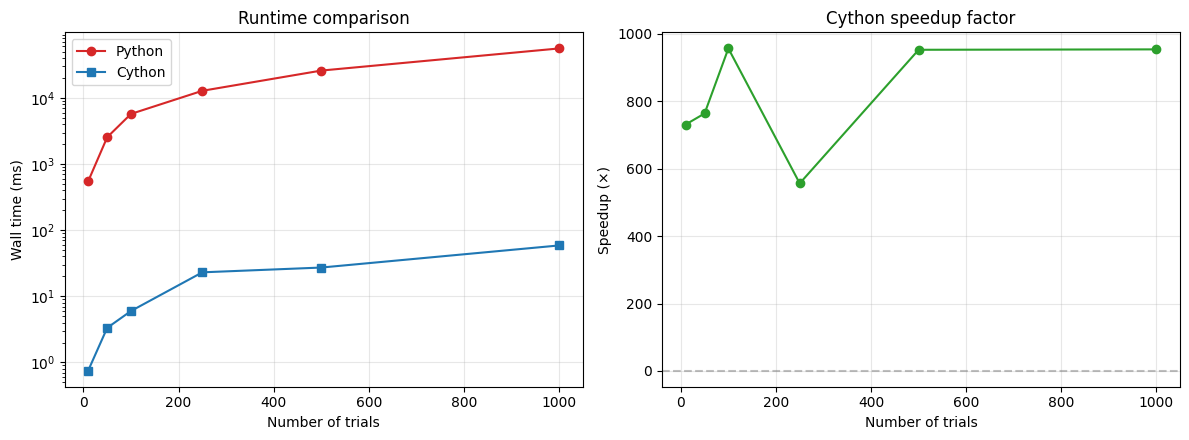

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
ax.plot(trial_counts, py_times * 1000, "o-", label="Python", color="#d62728")
ax.plot(trial_counts, cy_times * 1000, "s-", label="Cython", color="#1f77b4")
ax.set_xlabel("Number of trials")
ax.set_ylabel("Wall time (ms)")
ax.set_yscale("log")
ax.legend()
ax.set_title("Runtime comparison")
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(trial_counts, speedups, "o-", color="#2ca02c")
ax.set_xlabel("Number of trials")
ax.set_ylabel("Speedup (×)")
ax.set_title("Cython speedup factor")
ax.axhline(1, ls="--", color="gray", alpha=0.5)
ax.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 5. Distributional validation

Both simulators sample from the same stochastic process, so their RT
distributions should be statistically indistinguishable.  We compare them
with histograms and a two-sample Kolmogorov-Smirnov test.

In [9]:
N_VALID = 3000

cy_valid = simulate_addm(n_trials=N_VALID, random_state=99, **PARAMS)
py_valid_rts, py_valid_choices = simulate_python(N_VALID, PARAMS, seed=99)

cy_term = cy_valid["rt"] > 0
py_term = py_valid_rts > 0

cy_rts_v = cy_valid["rt"][cy_term]
cy_ch_v = cy_valid["choice"][cy_term]
py_rts_v = py_valid_rts[py_term]
py_ch_v = py_valid_choices[py_term]

print(f"Cython terminated: {cy_term.sum()} / {N_VALID}")
print(f"Python terminated: {py_term.sum()} / {N_VALID}")

Cython terminated: 3000 / 3000
Python terminated: 3000 / 3000


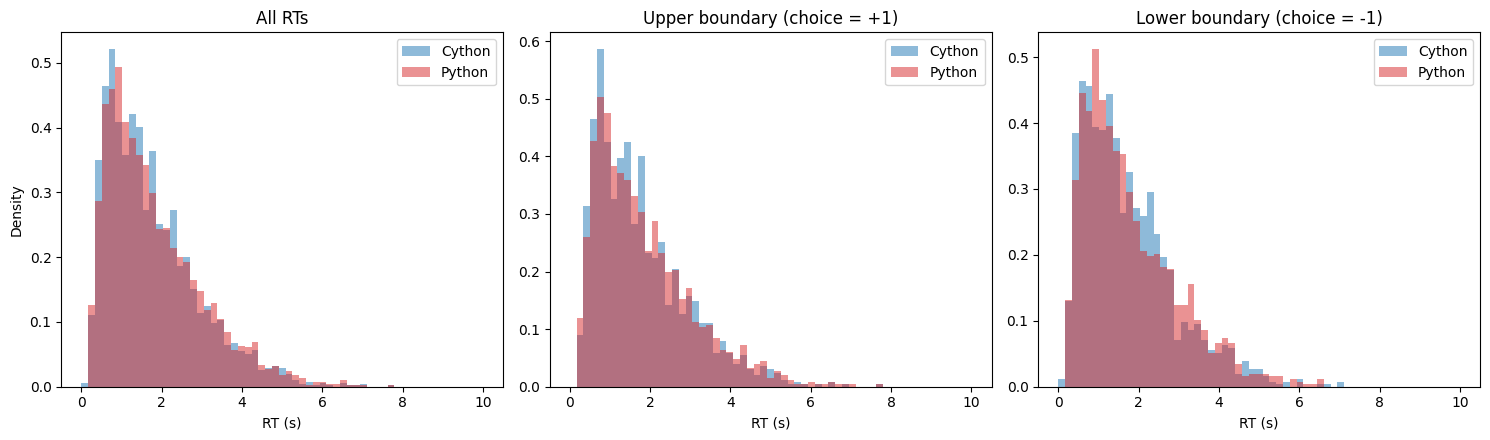

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
bins = np.linspace(0, PARAMS["max_t"], 60)

# --- All RTs ---
ax = axes[0]
ax.hist(cy_rts_v, bins=bins, alpha=0.5, density=True, label="Cython", color="#1f77b4")
ax.hist(py_rts_v, bins=bins, alpha=0.5, density=True, label="Python", color="#d62728")
ax.set_xlabel("RT (s)")
ax.set_ylabel("Density")
ax.set_title("All RTs")
ax.legend()

# --- Upper boundary (choice = +1) ---
ax = axes[1]
ax.hist(cy_rts_v[cy_ch_v == 1], bins=bins, alpha=0.5, density=True, label="Cython", color="#1f77b4")
ax.hist(py_rts_v[py_ch_v == 1], bins=bins, alpha=0.5, density=True, label="Python", color="#d62728")
ax.set_xlabel("RT (s)")
ax.set_title("Upper boundary (choice = +1)")
ax.legend()

# --- Lower boundary (choice = -1) ---
ax = axes[2]
ax.hist(cy_rts_v[cy_ch_v == -1], bins=bins, alpha=0.5, density=True, label="Cython", color="#1f77b4")
ax.hist(py_rts_v[py_ch_v == -1], bins=bins, alpha=0.5, density=True, label="Python", color="#d62728")
ax.set_xlabel("RT (s)")
ax.set_title("Lower boundary (choice = -1)")
ax.legend()

fig.tight_layout()
plt.show()

In [11]:
stat, p = ks_2samp(cy_rts_v, py_rts_v)
print(f"KS test (all RTs):      stat = {stat:.4f},  p = {p:.4f}")

stat_u, p_u = ks_2samp(cy_rts_v[cy_ch_v == 1], py_rts_v[py_ch_v == 1])
print(f"KS test (choice = +1):  stat = {stat_u:.4f},  p = {p_u:.4f}")

stat_l, p_l = ks_2samp(cy_rts_v[cy_ch_v == -1], py_rts_v[py_ch_v == -1])
print(f"KS test (choice = -1):  stat = {stat_l:.4f},  p = {p_l:.4f}")

print(f"\nChoice proportion (Cython):  {(cy_ch_v == 1).mean():.3f} upper,  {(cy_ch_v == -1).mean():.3f} lower")
print(f"Choice proportion (Python):  {(py_ch_v == 1).mean():.3f} upper,  {(py_ch_v == -1).mean():.3f} lower")

KS test (all RTs):      stat = 0.0273,  p = 0.2124
KS test (choice = +1):  stat = 0.0347,  p = 0.3222
KS test (choice = -1):  stat = 0.0367,  p = 0.2518

Choice proportion (Cython):  0.500 upper,  0.500 lower
Choice proportion (Python):  0.493 upper,  0.507 lower


## 6. Impact of boundary collapse on Gaussian budget

When `b > 0`, the boundaries cross at `t = a/b`.  The Cython simulator
exploits this to allocate fewer Gaussian draws, yielding further speedups
for steep collapse rates.

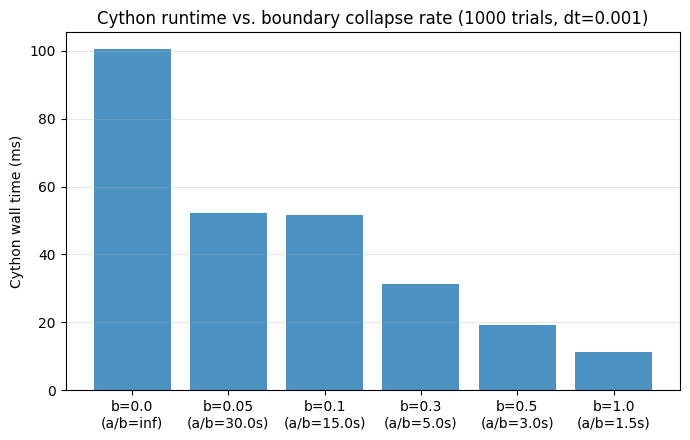

In [12]:
b_values = [0.0, 0.05, 0.1, 0.3, 0.5, 1.0]
cy_b_times = []

for b_val in b_values:
    p = {**PARAMS, "b": b_val}
    _ = simulate_addm(n_trials=10, random_state=0, **p)
    runs = []
    for i in range(3):
        t0 = time.perf_counter()
        simulate_addm(n_trials=N_TRIALS, random_state=SEED + i, **p)
        runs.append(time.perf_counter() - t0)
    cy_b_times.append(np.mean(runs))

collapse_times = [PARAMS["a"] / b if b > 0 else np.inf for b in b_values]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(range(len(b_values)), [t * 1000 for t in cy_b_times], color="#1f77b4", alpha=0.8)
ax.set_xticks(range(len(b_values)))
labels = []
for bv, ct in zip(b_values, collapse_times):
    ct_str = f"{ct:.1f}s" if np.isfinite(ct) else "inf"
    labels.append(f"b={bv}\n(a/b={ct_str})")
ax.set_xticklabels(labels)
ax.set_ylabel("Cython wall time (ms)")
ax.set_title(f"Cython runtime vs. boundary collapse rate ({N_TRIALS} trials, dt={PARAMS['dt']})")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## 7. Summary

| Metric | Python | Cython |
|--------|--------|--------|
| Inner loop | Pure Python Euler-Maruyama | Typed Cython `nogil` loop |
| RNG | Per-trial `np.random` calls | Batch Ziggurat via `rng.standard_normal` |
| Post-processing | N/A | Vectorized NumPy |
| Gaussian budget | Always `max_t / dt` | `min(a/b, max_t) / dt` |

The Cython simulator produces RT distributions indistinguishable from
the Python reference (KS test p >> 0.05) while running orders of magnitude
faster.